# Practice 7
This practice is part of the weekly IPB University practice questions along with the explanations of each question. This specific practice discusses about **1D arrays**.

**Question 1**

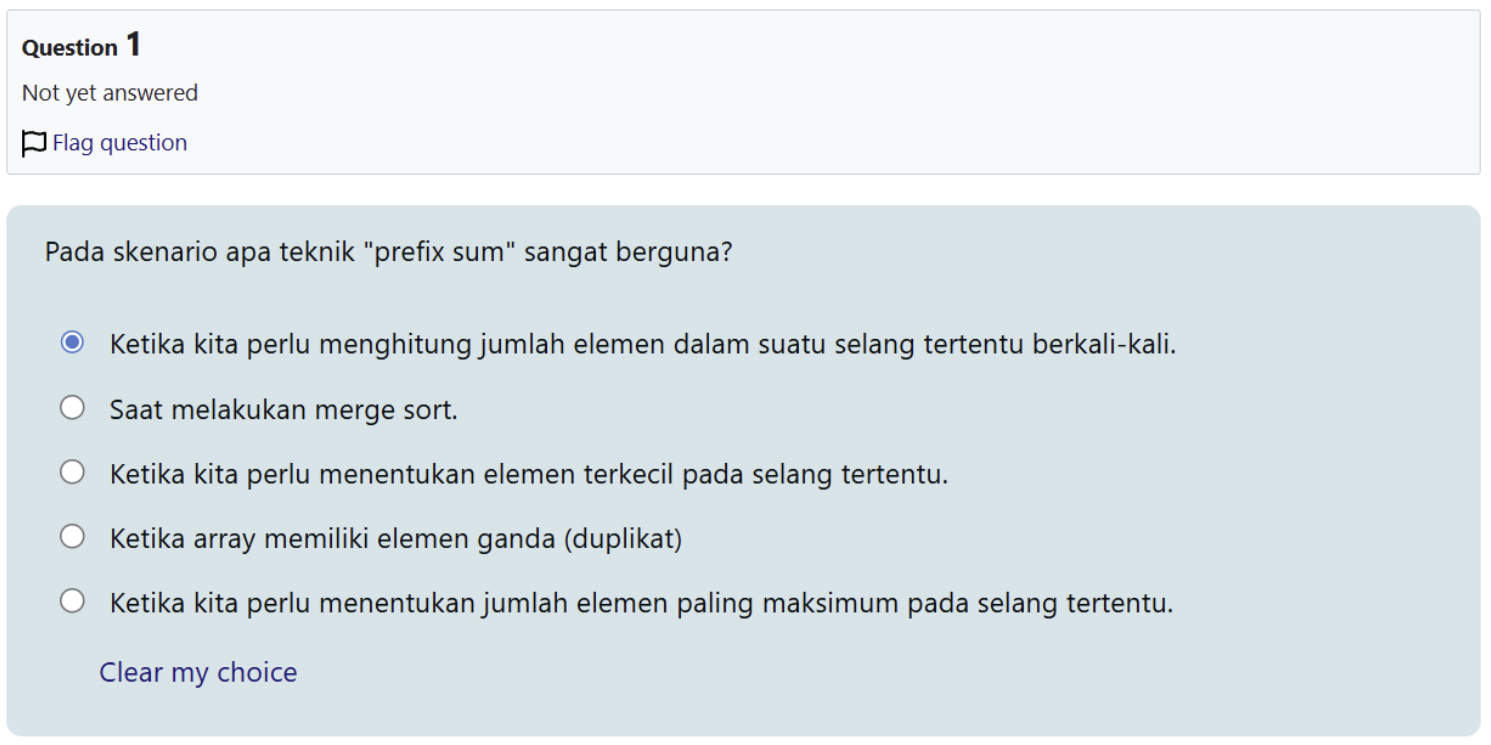

Teknik `Prefix Sum` (atau sering disebut `cumulative sum`) adalah teknik optimasi yang sangat efisien untuk menangani Range Sum Queries (pertanyaan mengenai jumlah elemen dalam rentang tertentu).

In [27]:
%%writefile practice7_1.c
#include <stdio.h>

int main() {
    int arr[] = {10, 20, 30, 40}; // Contoh data
    int n = 4;
    int ps[4];

    // Membangun Prefix Sum Array
    ps[0] = arr[0];
    for (int i = 1; i < n; i++) {
        ps[i] = ps[i - 1] + arr[i];
    }

    // Kasus 1: Rentang [0:2] (a = 0, b = 2)
    // Rumus: Total = PS[b]
    int sum02 = ps[2];

    // Kasus 2: Rentang [1:3] (a = 1, b = 3)
    // Rumus: Total = PS[b] - PS[a-1]
    int sum13 = ps[3] - ps[0];

    printf("Array: 10, 20, 30, 40\n");
    printf("Prefix Sum: %d, %d, %d, %d\n", ps[0], ps[1], ps[2], ps[3]);
    printf("Sum [0:2] = %d\n", sum02);
    printf("Sum [1:3] = %d\n", sum13);

    return 0;
}

Writing practice7_1.c


In [28]:
!gcc practice7_1.c -o practice7_1.exe && practice7_1.exe

Array: 10, 20, 30, 40
Prefix Sum: 10, 30, 60, 100
Sum [0:2] = 60
Sum [1:3] = 90


## **Analisis Rumus Prefix Sum**

Dalam perhitungan *Range Sum Query* (jumlah elemen dari indeks $a$ ke $b$), terdapat dua kondisi jika menggunakan array berbasis 0 (**0-based indexing**):

1. **Jika $a = 0$**: 
   Kita mengambil jumlah dari awal, sehingga rumusnya langsung:  
   $$\text{Total}(0, b) = PS[b]$$
2. **Jika $a > 0$**: 
   Kita harus membuang bagian yang tidak termasuk dalam rentang (elemen sebelum $a$), sehingga rumusnya:  
   $$\text{Total}(a, b) = PS[b] - PS[a-1]$$

---

### **Alternatif: 1-based Indexing**
Untuk menghindari pengecekan kondisi `if (a == 0)`, banyak programmer kompetitif menggunakan **1-based indexing**. 

**Caranya:**
* Ukuran array `PS` dibuat menjadi $n + 1$.
* Indeks `PS[0]` diisi dengan **0**.
* Data asli dimulai dari indeks 1.

**Keuntungan:**
Rumusnya menjadi universal untuk semua nilai $a$ dan $b$:
$$\text{Total}(a, b) = PS[b] - PS[a-1]$$
*(Jika $a=1$, maka $PS[a-1]$ adalah $PS[0]$ yang bernilai 0, sehingga tetap akurat).*

In [29]:
%%writefile practice7_1_alt.c
#include <stdio.h>

int main() {
    int arr[] = {0, 10, 20, 30, 40}; // Index 0 diabaikan
    int n = 4;
    int ps[5] = {0}; // PS[0] akan tetap 0

    // Membangun Prefix Sum (1-based)
    for (int i = 1; i <= n; i++) {
        ps[i] = ps[i - 1] + arr[i];
    }

    // Mencari sum [1:3] dan [2:4] (Ekivalen dengan 0-based [0:2] dan [1:3])
    // Rumus universal: PS[b] - PS[a-1]
    int sum13 = ps[3] - ps[1 - 1]; // [1:3] -> PS[3] - PS[0]
    int sum24 = ps[4] - ps[2 - 1]; // [2:4] -> PS[4] - PS[1]

    printf("--- 1-based Indexing ---\n");
    printf("Sum indices 1-3: %d\n", sum13);
    printf("Sum indices 2-4: %d\n", sum24);

    return 0;
}

Writing practice7_1_alt.c


In [30]:
!gcc practice7_1_alt.c -o practice7_1_alt.exe && practice7_1_alt.exe

--- 1-based Indexing ---
Sum indices 1-3: 60
Sum indices 2-4: 90


**Question 2**

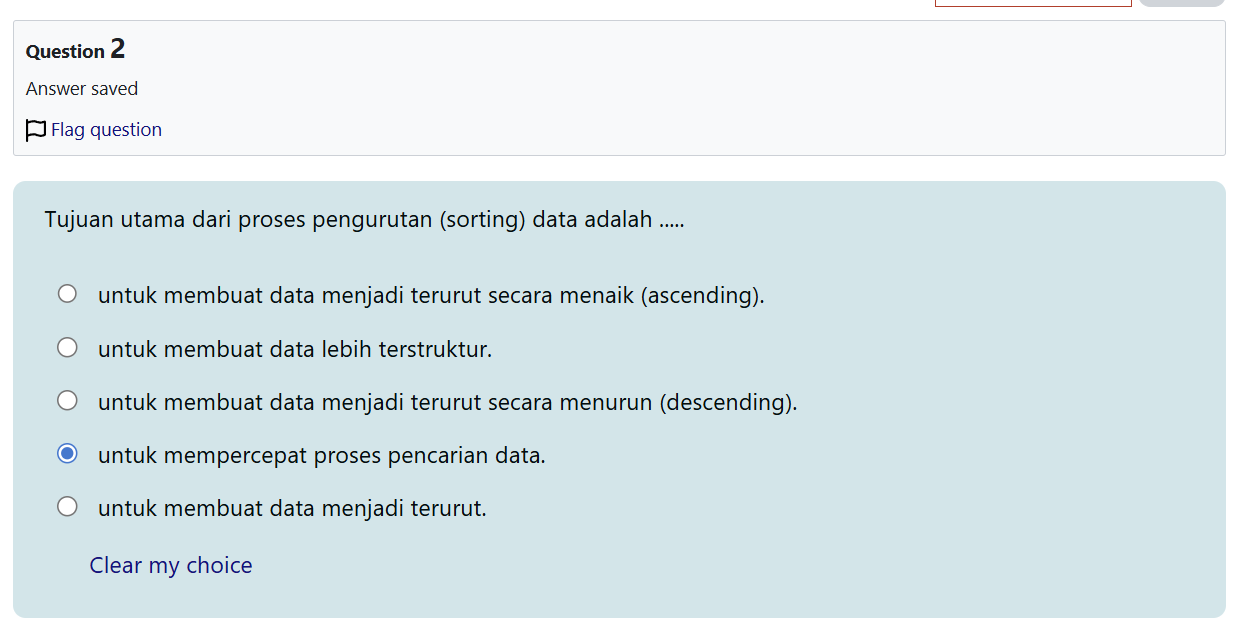

Meskipun secara definisi sorting adalah proses menyusun data (baik menaik maupun menurun), tujuan fungsional atau alasan mengapa kita melakukan pengurutan dalam ilmu komputer adalah untuk efisiensi algoritma lain, terutama pencarian (searching).

**Question 3**

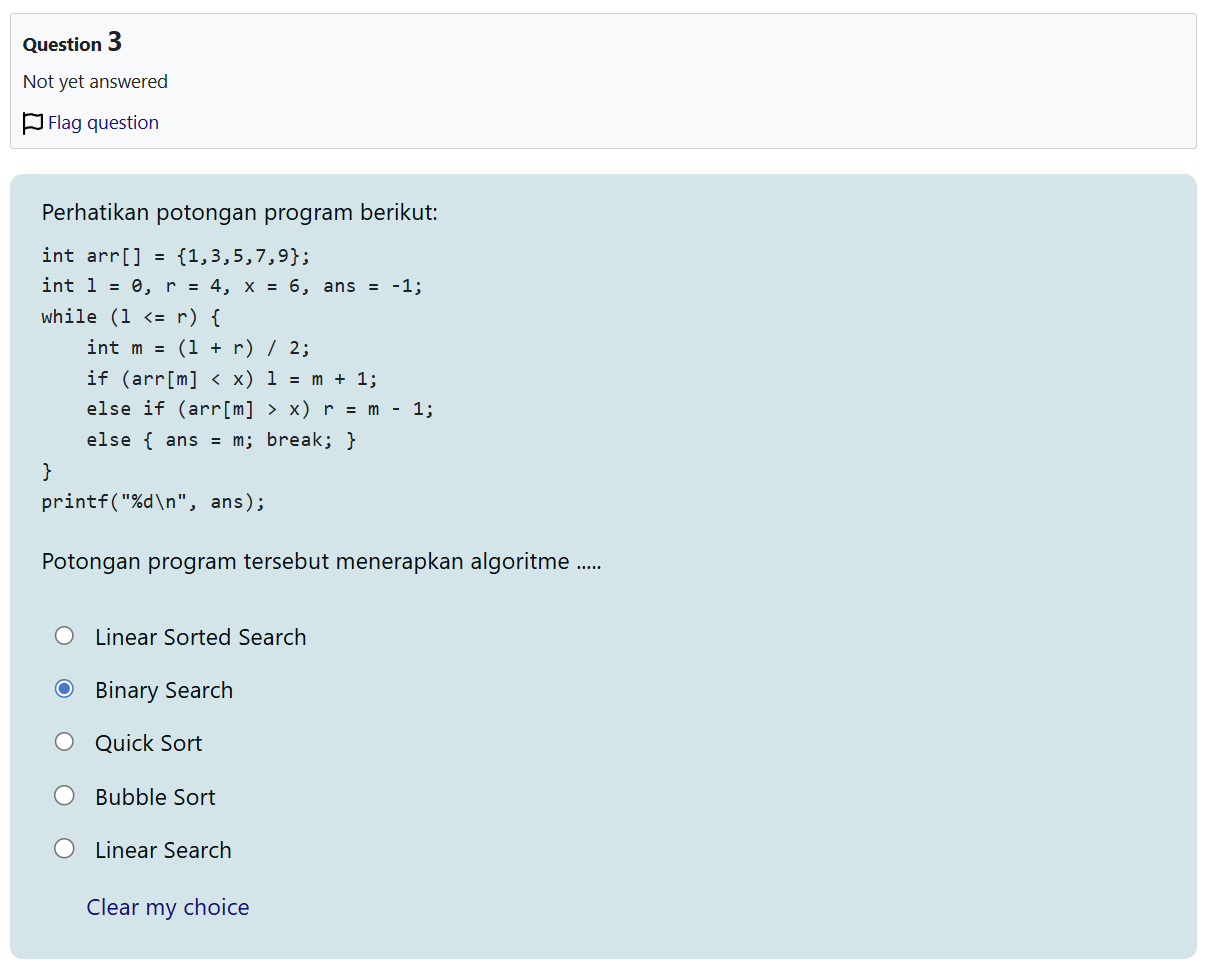

`Binary search` adalah salah satu algoritma searching yang membutuhkan list yang sudah terurut. Teknik utamanya adalah sebagai berikut:
1. Mengambil titik `min` dan `max` dari algoritma.
2. Mengambil titik `mid` dengan rumus $(min + max)/2$.
3. Bandingkan `mid` dengan `target`.
    * **i.** Apabila $target < mid$, maka `target` ada di sebelah kiri dari `mid`.
        * **a.** Ubah `max` = elemen sebelum `mid`.
        * **b.** Ulang ke tahap 1.
    * **ii.** Apabila $target > mid$, maka `target` ada di sebelah kanan dari `mid`.
        * **a.** Ubah `min` = elemen setelah `mid`.
        * **b.** Ulang ke tahap 1.
    * **iii.** Apabila $ `target` = `mid`$, maka ditemukan!


**Question 4**

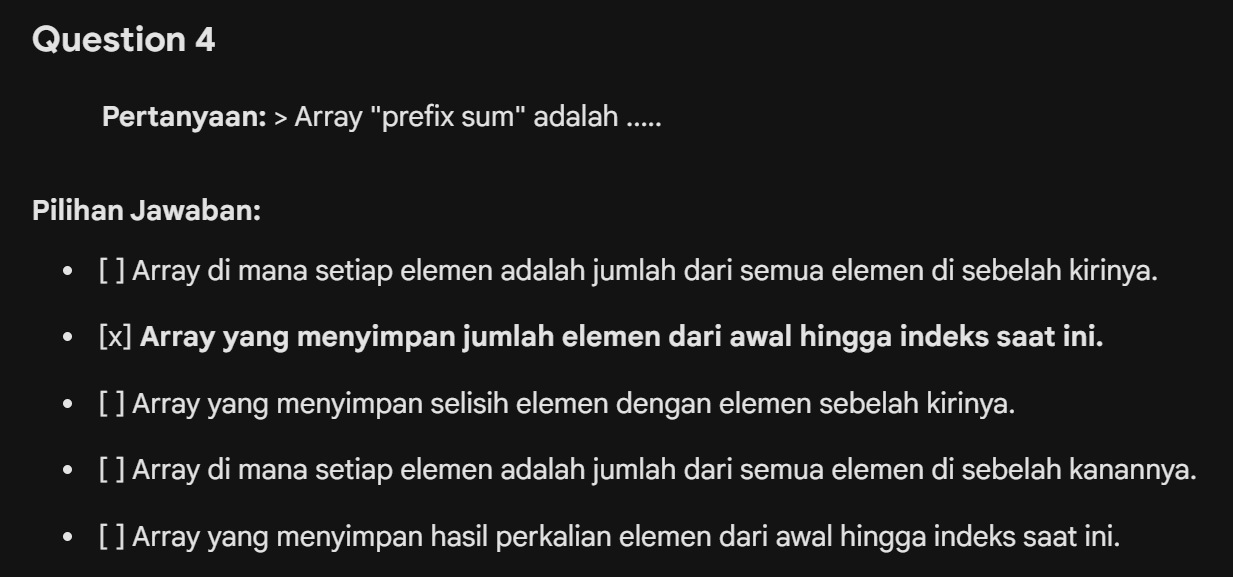

Array **Prefix Sum** adalah array yang menyimpan jumlah elemen dari awal hingga indeks saat ini.

* **Konsep Utama:**
    Setiap elemen pada indeks $i$ dalam array prefix sum ($P$) merupakan hasil akumulasi dari elemen pertama hingga indeks tersebut pada array asli ($A$).
* **Rumus Matematis:**
    $$P[i] = \sum_{j=0}^{i} A[j]$$
* **Kegunaan:**
    Sangat efektif untuk menyelesaikan persoalan *Range Sum Query* dengan kompleksitas waktu $O(1)$ setelah proses *preprocessing* selesai.

**Question 5**

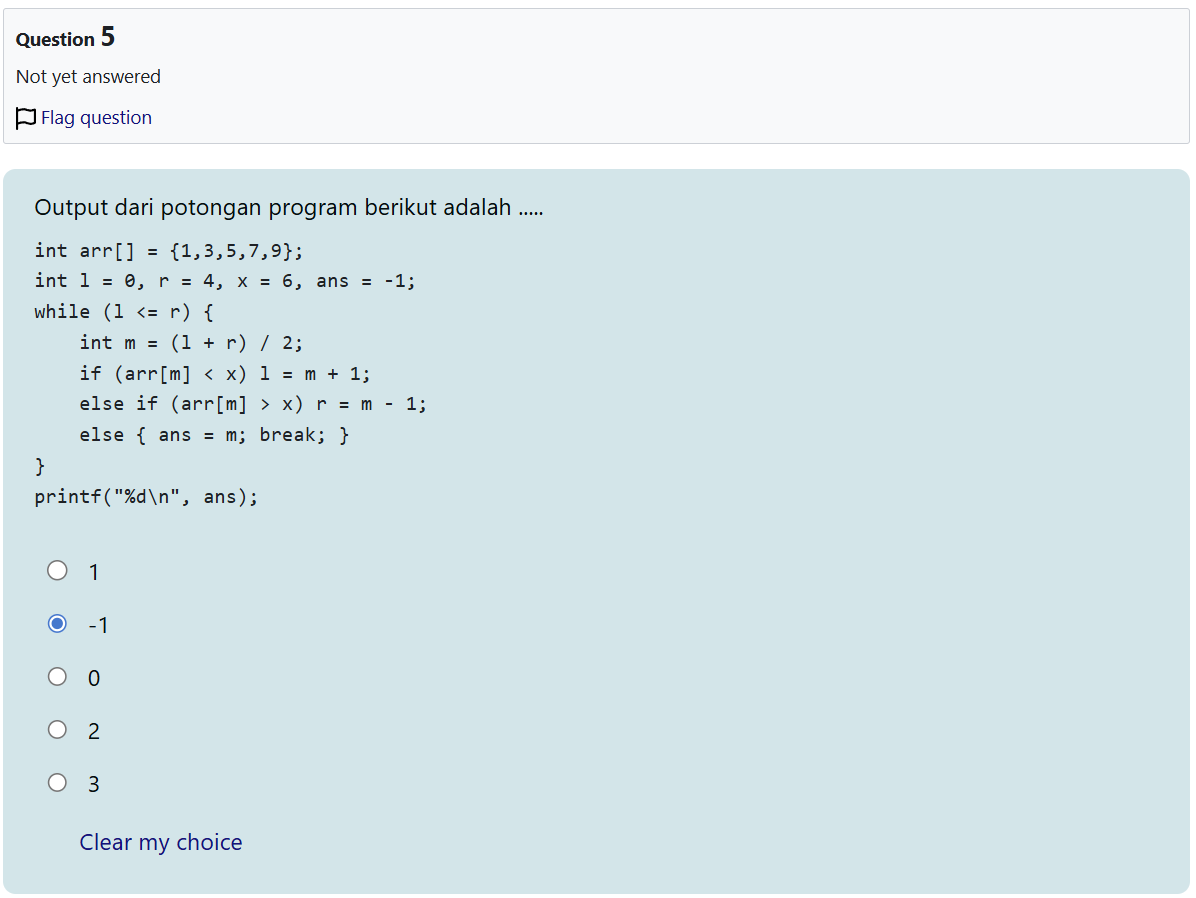

In [31]:
%%writefile practice7_5.c
#include <stdio.h>

int main() {
  int elements[] = {1, 3, 5, 7, 9};
  int left = 0;
  int right = 4;
  int target = 6;
  int resultIndex = -1;

  while (left <= right) {
    int mid = (left + right) / 2;

    if (elements[mid] < target) {
      left = mid + 1;
    } 
    else if (elements[mid] > target) {
      right = mid - 1;
    } 
    else {
      resultIndex = mid;
      break;
    }
  }

  // Mencetak indeks hasil pencarian
  printf("%d\n", resultIndex);

   return 0;
}

Overwriting practice7_5.c


In [32]:
!gcc practice7_5.c -o practice7_5.exe && practice7_5.exe

-1


The code above is a `binary search` code that returns -1 which means sthe element is not found (`target` = 6).

**Question 6**

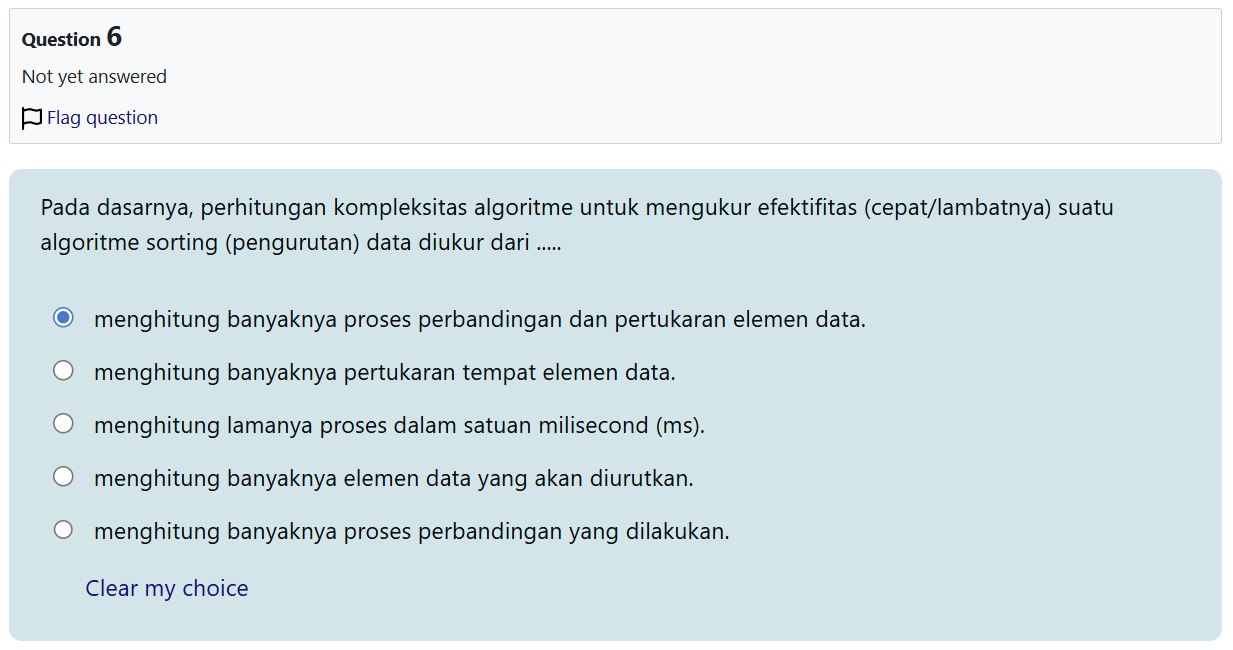

Dalam analisis algoritme (khususnya sorting), kita tidak mengukur kecepatan menggunakan satuan waktu seperti detik atau milisekon. Hal ini dikarenakan waktu eksekusi sangat bergantung pada perangkat keras (hardware), sistem operasi, dan bahasa pemrograman yang digunakan. Oleh karena itu, ilmuwan komputer menggunakan operasi dasar sebagai unit pengukuran:
1. **Proses Perbandingan (Comparison):** Dilakukan untuk _menentukan urutan antara dua elemen_ (misalnya: apakah A[i] > A[j]$?). Ini adalah operasi logika yang dominan pada algoritme seperti Quick Sort atau Merge Sort.
2. **Proses Pertukaran (Swap/Movement):** Dilakukan untuk _memindahkan elemen ke posisi yang benar_ setelah hasil perbandingan diketahui. Banyaknya pertukaran mencerminkan seberapa besar upaya fisik (perpindahan data di memori) yang dilakukan algoritme.

**Question 7**

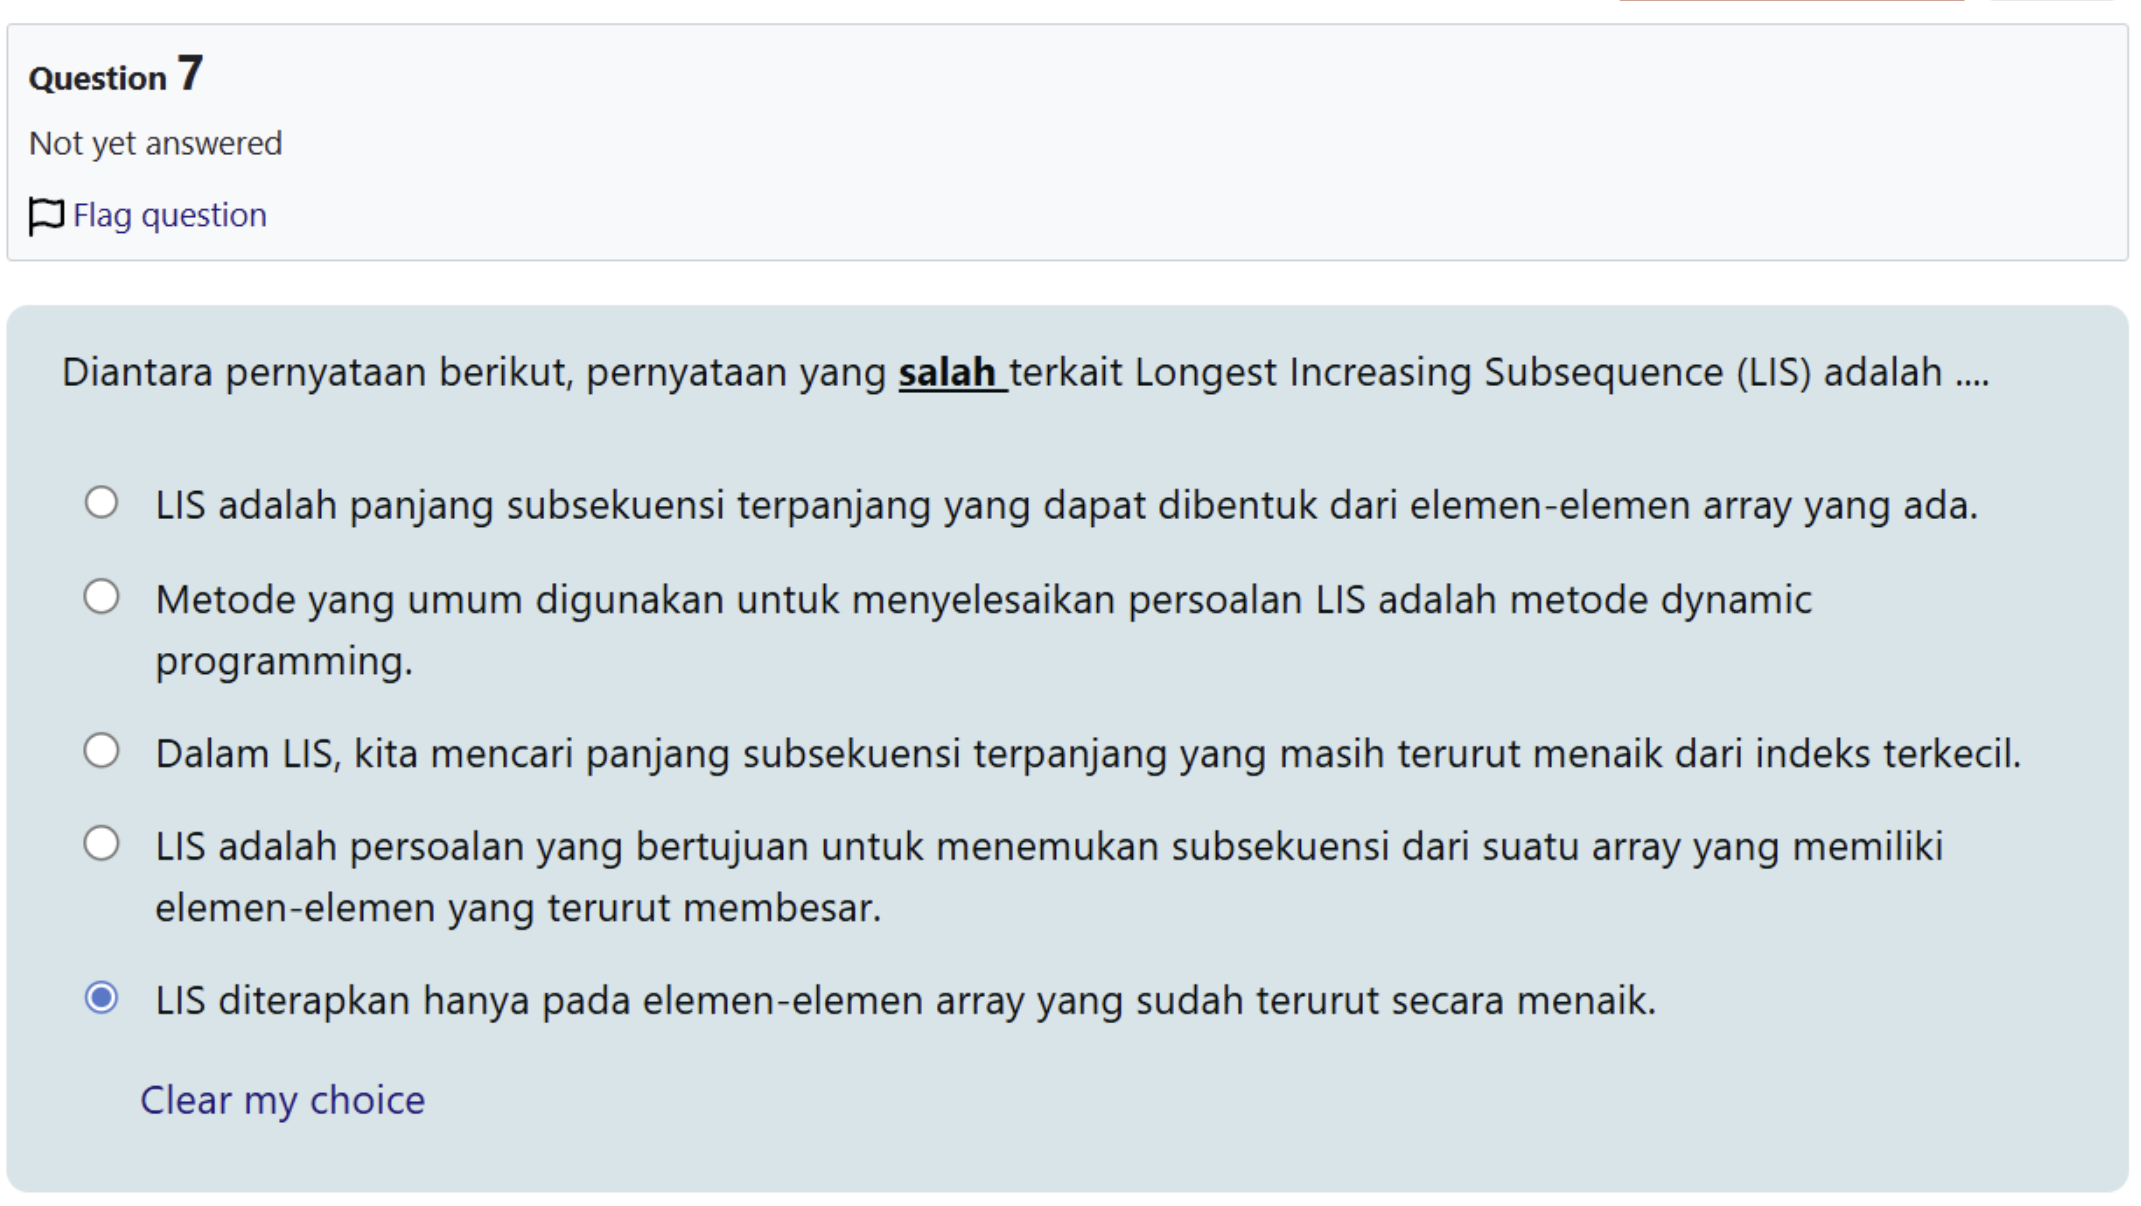

Tujuan utama dari `Longest Increasing Subsequence (LIS)` adalah untuk **mencari subsekuensi terpanjang yang terurut menaik di dalam sebuah array yang acak** (tidak terurut). Jika sebuah array sudah terurut secara menaik (misal: `[1, 2, 3, 4, 5]`), maka persoalan LIS menjadi tidak relevan (trivial) karena seluruh elemen tersebut adalah LIS itu sendiri dengan panjang $n$.

In [33]:
%%writefile practice7_7.c
#include <stdio.h>

int find_lis_length(int arr[], int n) {
    int dp[n];
    int max_lis = 0;

    // Inisialisasi: setiap elemen adalah LIS dengan panjang 1
    for (int i = 0; i < n; i++) {
        dp[i] = 1;
    }

    // Membangun tabel DP
    for (int i = 1; i < n; i++) {
        for (int j = 0; j < i; j++) {
            if (arr[i] > arr[j] && dp[i] < dp[j] + 1) {
                dp[i] = dp[j] + 1;
            }
        }
    }

    // Mencari nilai tertinggi dalam array dp
    for (int i = 0; i < n; i++) {
        if (max_lis < dp[i]) {
            max_lis = dp[i];
        }
    }

    return max_lis;
}

int main() {
    int data[] = {3, 10, 2, 11};
    int n = sizeof(data) / sizeof(data[0]);

    int result = find_lis_length(data, n);
    printf("Panjang Longest Increasing Subsequence adalah: %d\n", result);

    return 0;
}

Overwriting practice7_7.c


In [34]:
!gcc practice7_7.c -o practice7_7.exe && practice7_7.exe

Panjang Longest Increasing Subsequence adalah: 3


## **LIS Trace Table: [3, 10, 2, 11]**

Berikut adalah tabel penelusuran (*trace table*) untuk algoritme **Longest Increasing Subsequence** dengan array input `[3, 10, 2, 11]`.

| Langkah ($i$) | Nilai `arr[i]` | Pembanding ($j$) | Nilai `arr[j]` | Kondisi (`arr[i] > arr[j]`) | Status Array `dp` | Penjelasan |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Awal** | - | - | - | - | `[1, 1, 1, 1]` | Inisialisasi: setiap elemen minimal panjangnya 1. |
| **$i = 1$** | **10** | $j = 0$ | 3 | **True** (10 > 3) | `[1, 2, 1, 1]` | 10 memperpanjang 3. $dp[1] = dp[0] + 1 = 2$. |
| **$i = 2$** | **2** | $j = 0$ | 3 | **False** (2 < 3) | `[1, 2, 1, 1]` | Tidak ada perubahan. |
| | | $j = 1$ | 10 | **False** (2 < 10) | `[1, 2, 1, 1]` | Tidak ada perubahan. |
| **$i = 3$** | **11** | $j = 0$ | 3 | **True** (11 > 3) | `[1, 2, 1, 2]` | 11 memperpanjang 3. $dp[3] = dp[0] + 1 = 2$. |
| | | $j = 1$ | 10 | **True** (11 > 10) | `[1, 2, 1, 3]` | 11 memperpanjang 10. $dp[3] = dp[1] + 1 = 3$. |
| | | $j = 2$ | 2 | **True** (11 > 2) | `[1, 2, 1, 3]` | 11 > 2, tapi $dp[2]+1=2$ (lebih kecil dari 3). Tetap 3. |

### **Hasil Akhir**
* **Array `dp` Terakhir:** `[1, 2, 1, 3]`
* **Panjang LIS (Nilai Max):** **3**
* **Subsekuensi Terbentuk:** `[3, 10, 11]`

**Question 8**

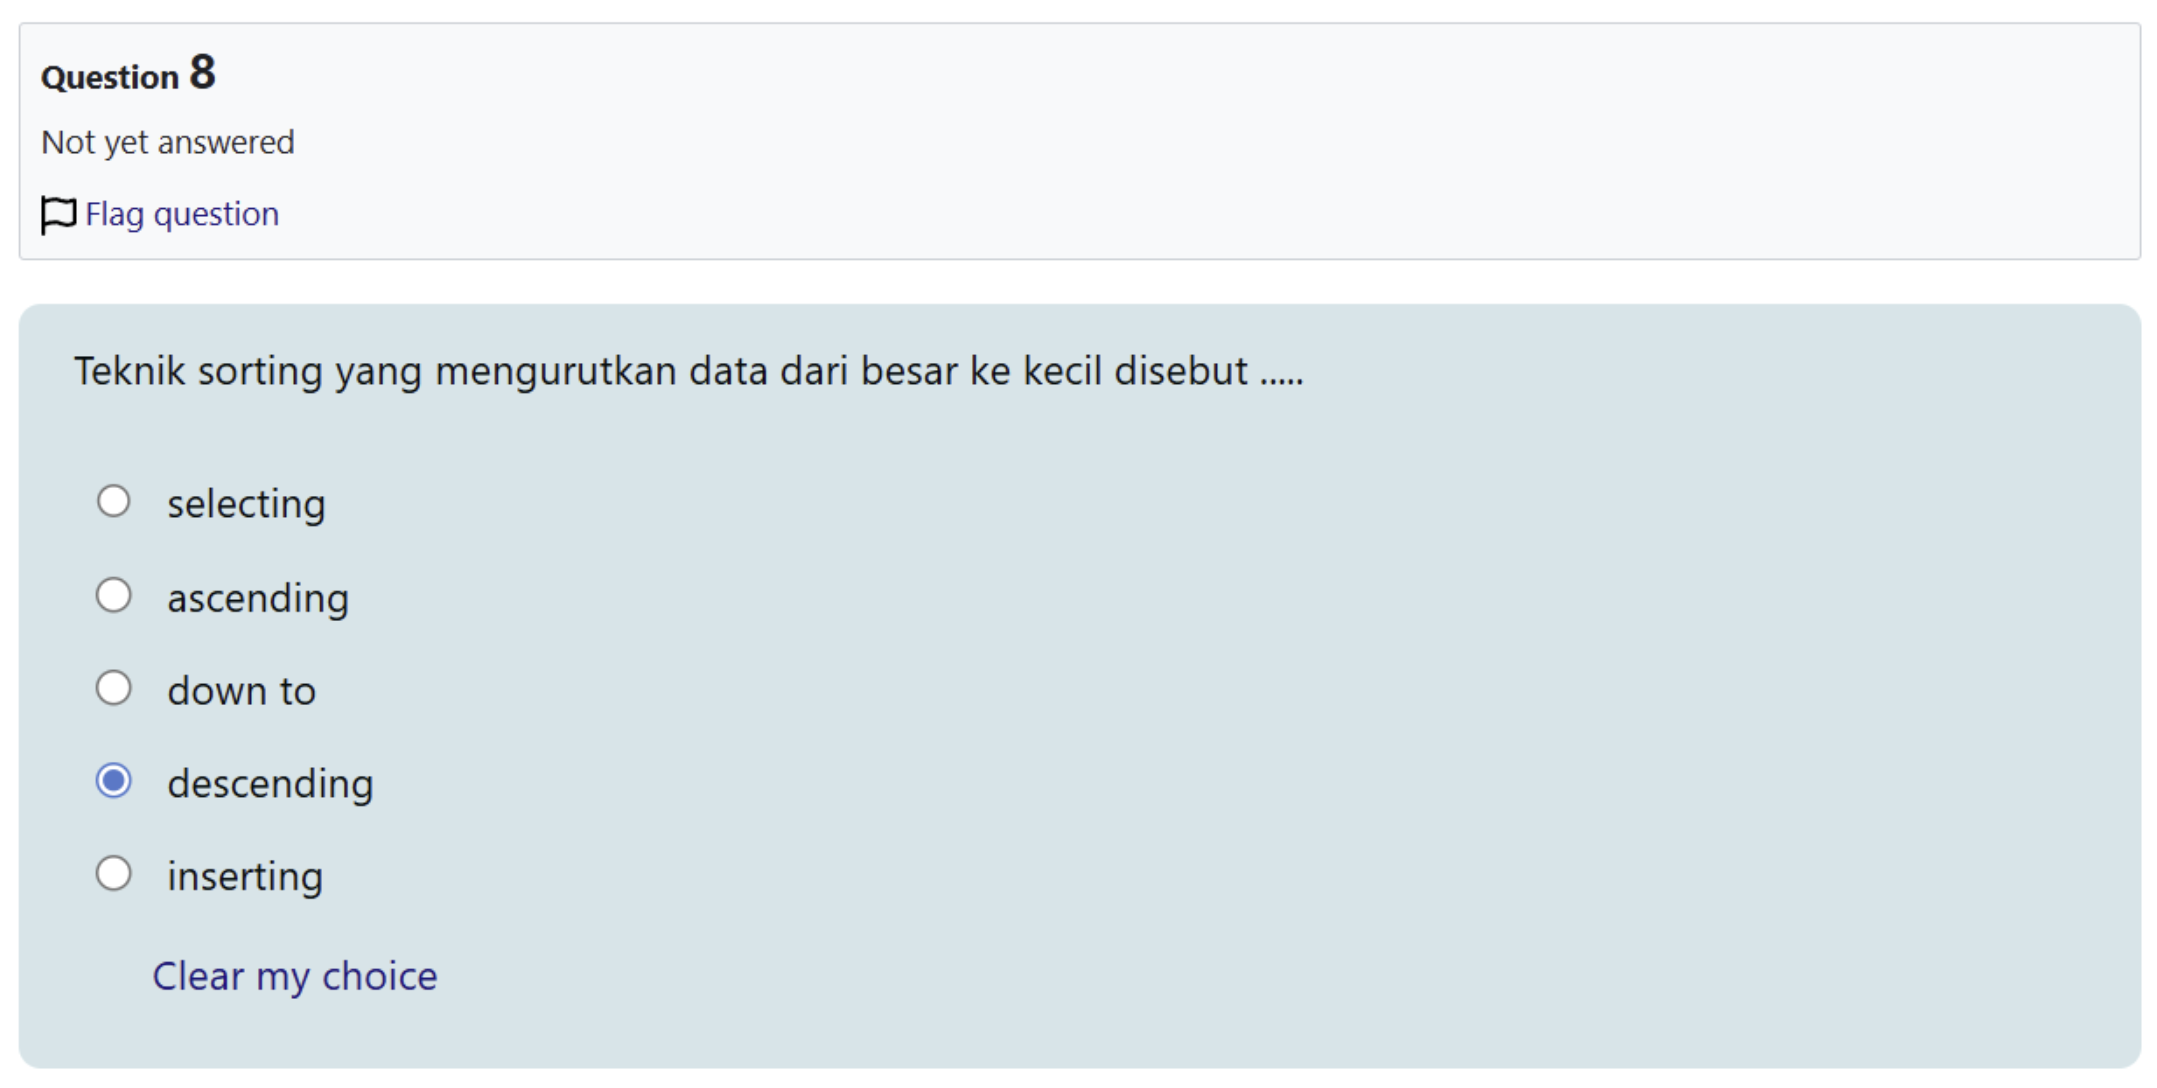

**Question 9**

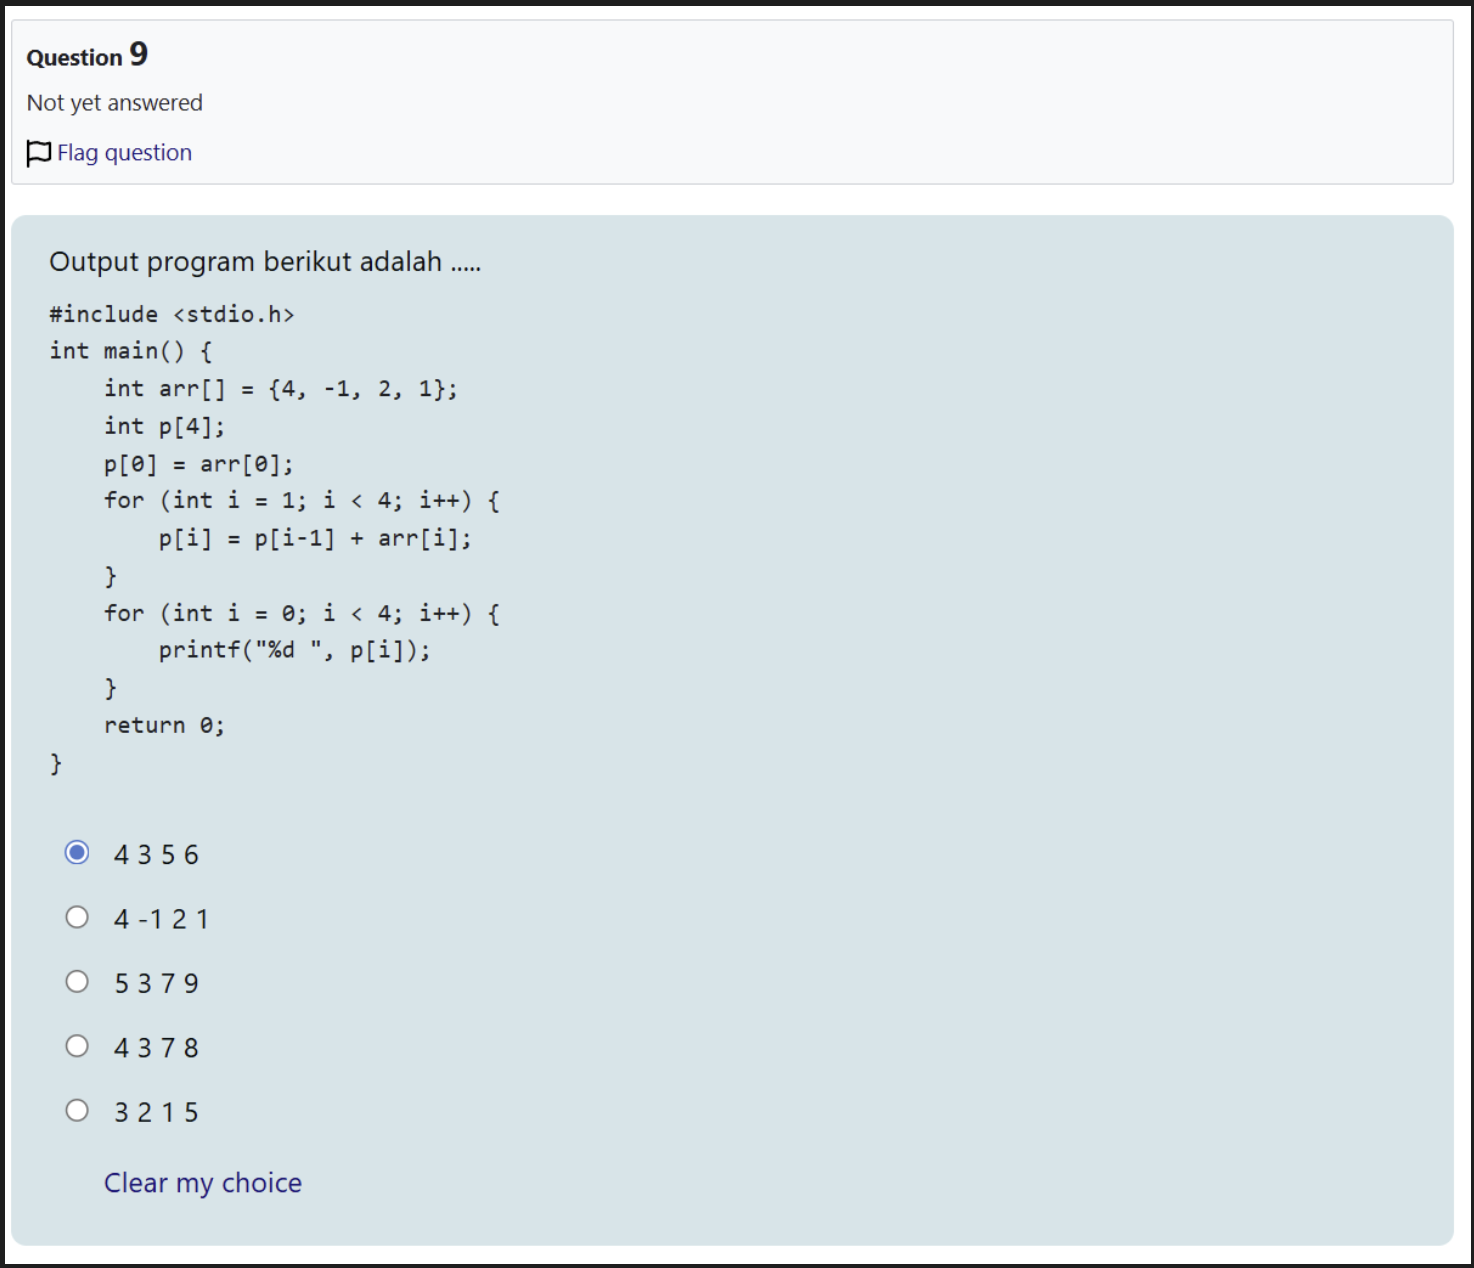

In [35]:
%%writefile practice7_9.c
#include <stdio.h>

int main() {
    // Array input
    int arr[] = {4, -1, 2, 1};
    int n = 4;
    int p[4];

    // Inisialisasi elemen pertama prefix sum
    p[0] = arr[0];

    // Menghitung prefix sum untuk elemen-elemen selanjutnya
    for (int i = 1; i < n; i++) {
        p[i] = p[i - 1] + arr[i];
    }

    // Mencetak hasil array prefix sum
    for (int i = 0; i < n; i++) {
        printf("%d ", p[i]);
    }
    printf("\n");

    return 0;
}

Overwriting practice7_9.c


In [36]:
!gcc practice7_9.c -o practice7_9.exe && practice7_9.exe

4 3 5 6 


## **Penjelasan Kode: Algoritme Prefix Sum**

Program ini mengimplementasikan teknik **Prefix Sum** (penjumlahan kumulatif). Setiap elemen pada array hasil `p` menyimpan jumlah total elemen dari awal array `arr` hingga indeks tersebut.

### **Logika Perhitungan**
1. **Inisialisasi:** Elemen pertama array prefix sum selalu sama dengan elemen pertama array asli ($p[0] = arr[0]$).
2. **Iterasi:** Untuk indeks $i > 0$, nilainya dihitung dengan menjumlahkan nilai prefix sebelumnya dengan elemen array asli saat ini:
   $$p[i] = p[i-1] + arr[i]$$

### **Trace Table (Penelusuran Variabel)**
Array Input: `arr = {4, -1, 2, 1}`

| Iterasi ($i$) | Operasi | Perhitungan | Hasil $p[i]$ | Status Array `p` |
| :--- | :--- | :--- | :--- | :--- |
| **Awal** | `p[0] = arr[0]` | `4` | **4** | `[4, ?, ?, ?]` |
| **$i = 1$** | `p[1] = p[0] + arr[1]` | `4 + (-1)` | **3** | `[4, 3, ?, ?]` |
| **$i = 2$** | `p[2] = p[1] + arr[2]` | `3 + 2` | **5** | `[4, 3, 5, ?]` |
| **$i = 3$** | `p[3] = p[2] + arr[3]` | `5 + 1` | **6** | `[4, 3, 5, 6]` |

**Output Program:** `4 3 5 6`

**Question 10**

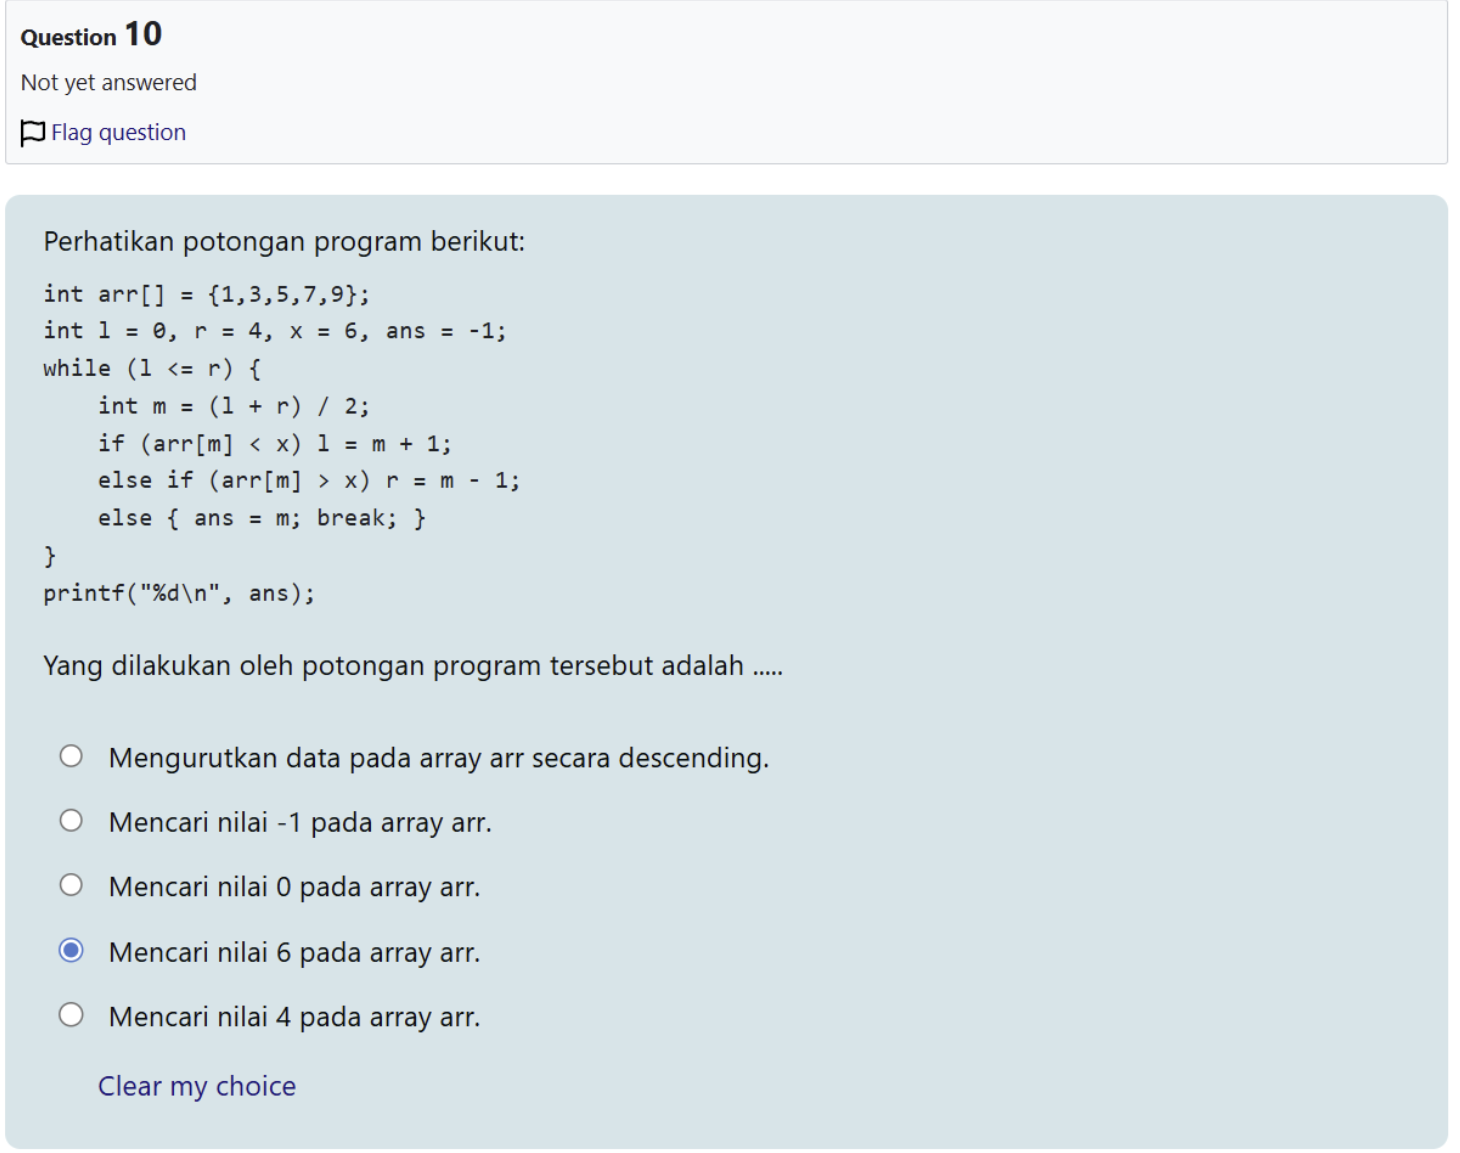